# Factorization Test: Amplitudes

This notebook evaluates the factorization properties of individual Sivers amplitudes and the full $A_{2B}$ denominator.
The evaluations are performed on the $(x, b_T)$ grid and tested using ratio tests:
- $R_b(x) = 	ilde{A}(x, b_T) / 	ilde{A}(x, b_{T, \text{ref}})$
- $R_x(b) = 	ilde{A}(x_i, b_T) / 	ilde{A}(x_{\text{ref}}, b_T)$

In [13]:
import h5py
import numpy as np
import gvar as gv
import lsqfit
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# Configuration
DATA_DIR = "/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/TMD_fit/h5data"
lata = 0.11403  # lattice spacing in fm
pl_to_zeta = {-4: 0.785756, -3: 0.539684, -2: 0.294367, -1: 0.090772}
PL_list = [-2, -3, -4]
PL_LIST_FINITE = [-1, -2, -3, -4]
bminfit = 3
etamin, etamax = 6, 10
param_names = ['a_re', 'c_re', 'j_re', 'd_re', 'a_im', 'c_im', 'j_im', 'd_im', 'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']

def Jackknife(datalist):
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N):
        theta_nminus_theta_bar.append(np.square(datalist[i] - theta_bar))
    sigma_sq = ((N - 1) / N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    import math
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params

def fit_param_linear(inv_zeta_vals, param_jk_samples):
    N_PL, N_JK = param_jk_samples.shape
    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))
    def fcn(x, p): return p['c0'] + p['c1'] * x**2
    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000)}
    c0_jk, c1_jk, chi2_dof = [], [], []
    cov_y_eval = gv.evalcov(y_gvar)
    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])
    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)

def jk_stats(arr, axis=0):
    N = arr.shape[axis]
    m = np.mean(arr, axis=axis)
    e = np.sqrt(((N - 1) / N) * np.sum((arr - np.expand_dims(m, axis))**2, axis=axis))
    return m, e

def build_extrapolated_params(PL_list, bminfit, etamin, etamax, data_dir=DATA_DIR):
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    init_filename = f"{data_dir}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])
    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}
    for i, pl in enumerate(sorted_PL_list):
        filename = f"{data_dir}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']
        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']
        raw_data['a_reA12B'][i, :] = params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']
    extrapolated_jk = {}
    for p_name in param_names:
        c0_jk, c1_jk, chi2 = fit_param_linear(inv_zeta_vals, raw_data[p_name])
        extrapolated_jk[p_name] = c0_jk
    return extrapolated_jk, raw_data, sorted_PL_list

def load_raw_params_for_pl(pl, data_dir=DATA_DIR):
    filename = f"{data_dir}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
    params = load_params_from_h5(filename)
    p = {}
    p['a_re'] = params['a_re']
    p['c_re'] = params['c_re'] / (pl**2)
    p['j_re'] = params['j_re']
    p['d_re'] = params['d_re']
    p['a_im'] = params['a_im'] / pl
    p['c_im'] = params['c_im'] / (pl**2)
    p['j_im'] = params['j_im']
    p['d_im'] = params['d_im']
    p['a_reA12B'] = params['a_reA12B']
    p['c_reA12B'] = params['c_reA12B'] / (pl**2)
    p['j_reA12B'] = params['j_reA12B']
    p['d_reA12B'] = params['d_reA12B']
    return p

extrapolated_jk, raw_data, sorted_PL_list = build_extrapolated_params(PL_list, bminfit, etamin, etamax)
finite_pl_params = {pl: load_raw_params_for_pl(pl) for pl in PL_LIST_FINITE}

def mask_near_pole(ref_jk, n_sigma=2.0, axis=0, label=None):
    m, e = jk_stats(ref_jk, axis=axis)
    # Disabled by user request to show the full x range
    bad = np.zeros_like(m, dtype=bool)
    # if label is not None and bad.any():
    #     print(f"  [pole guard] {label}: masked {bad.sum()}/{bad.size} points")
    return bad

def eval_obs_jk(p_dict, x_grid, b2):
    x_grid = np.asarray(x_grid, dtype=float)
    abs_x = np.abs(x_grid).copy()
    abs_x[abs_x == 0] = 1e-12
    safe_x = np.where(x_grid == 0, 1e-12, x_grid)

    a_R, c_R = p_dict['a_re'][:, None], p_dict['c_re'][:, None]
    d_R, j_R = (1.0 + p_dict['d_re'] * b2)[:, None], p_dict['j_re'][:, None]

    a_I, c_I = p_dict['a_im'][:, None], p_dict['c_im'][:, None]
    d_I, j_I = (1.0 + p_dict['d_im'] * b2)[:, None], p_dict['j_im'][:, None]

    a_A, c_A = -p_dict['a_reA12B'][:, None], p_dict['c_reA12B'][:, None]
    d_A, j_A = (1.0 + p_dict['d_reA12B'] * b2)[:, None], p_dict['j_reA12B'][:, None]

    cd_R = c_R / d_R
    t1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R / 2) * d_R**(-j_R)) / gamma(j_R)
    re = t1_R * (abs_x[None, :]**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x[None, :] / np.sqrt(cd_R))

    cd_I = c_I / d_I
    t1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2 * j_I)) * d_I**(-j_I)) / gamma(j_I)
    im = t1_I * (safe_x[None, :] * abs_x[None, :]**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x[None, :])

    cd_A = c_A / d_A
    t1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A / 2) * d_A**(-j_A)) / gamma(j_A)
    reA12B = -2 * t1_A * (abs_x[None, :]**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x[None, :] / np.sqrt(cd_A))

    denom = re - im 
    return {'reA12B': reA12B, 're': re, 'im': im, 'denom': denom}

def eval_obs_over_b2(p_dict, x_val, b2_grid):
    x_arr = np.array([x_val])
    out = {'reA12B': [], 're': [], 'im': [], 'denom': []}
    for b2 in b2_grid:
        res = eval_obs_jk(p_dict, x_arr, b2)
        for k in out:
            out[k].append(res[k][:, 0])
    for k in out:
        out[k] = np.stack(out[k], axis=1)
    return out

x_grid = np.linspace(0.001, 1.0, 400)
b2_ref = 9.0
b2_fan = [16.0, 25.0, 36.0, 49.0]
bT_ref_fm = np.round(np.sqrt(b2_ref) * lata, 2)
colors_fan = plt.cm.viridis(np.linspace(0.15, 0.9, len(b2_fan)))

observables = ['reA12B', 're', 'im', 'denom']
obs_labels = {'reA12B': r'-2\widetilde{A}^{[x]\mathrm{Re}}_{12B}', 're': r'\widetilde{A}^{[x]\mathrm{Re}}_{2B}', 'im': r'i\widetilde{A}^{[x]\mathrm{Im}}_{2B}', 'denom': r'\widetilde{A}^{[x]}_{2B}'}

|b_T| range: [0.3421, 0.9403] fm (60 points, fixed for all observables/windows)

=== \tilde{A}_{12B}^{Re}  (reA12B) ===
  x in [0.0, 1.0]  (converged in 5 iterations): 0.0804(18)
  x in [0.1, 0.9]  (converged in 4 iterations): 0.0573(26)
  x in [0.2, 0.8]  (converged in 4 iterations): 0.0397(24)
  x in [0.3, 0.8]  (converged in 4 iterations): 0.0303(21)

=== \tilde{A}_{2B}^{Re}  (re) ===
  x in [0.0, 1.0]  (converged in 5 iterations): 0.08138(65)
  x in [0.1, 0.9]  (converged in 5 iterations): 0.0718(36)
  x in [0.2, 0.8]  (converged in 4 iterations): 0.0581(55)
  x in [0.3, 0.8]  (converged in 4 iterations): 0.0478(56)

=== \tilde{A}_{2B}^{Im}  (im) ===
  x in [0.0, 1.0]  (converged in 5 iterations): 0.107(18)
  x in [0.1, 0.9]  (converged in 5 iterations): 0.0868(30)
  x in [0.2, 0.8]  (converged in 4 iterations): 0.0578(28)
  x in [0.3, 0.8]  (converged in 4 iterations): 0.0425(23)

=== \tilde{A}_{2B}  (denom) ===
  x in [0.0, 1.0]  (converged in 6 iterations): 0.1943(63)
  x in [0.

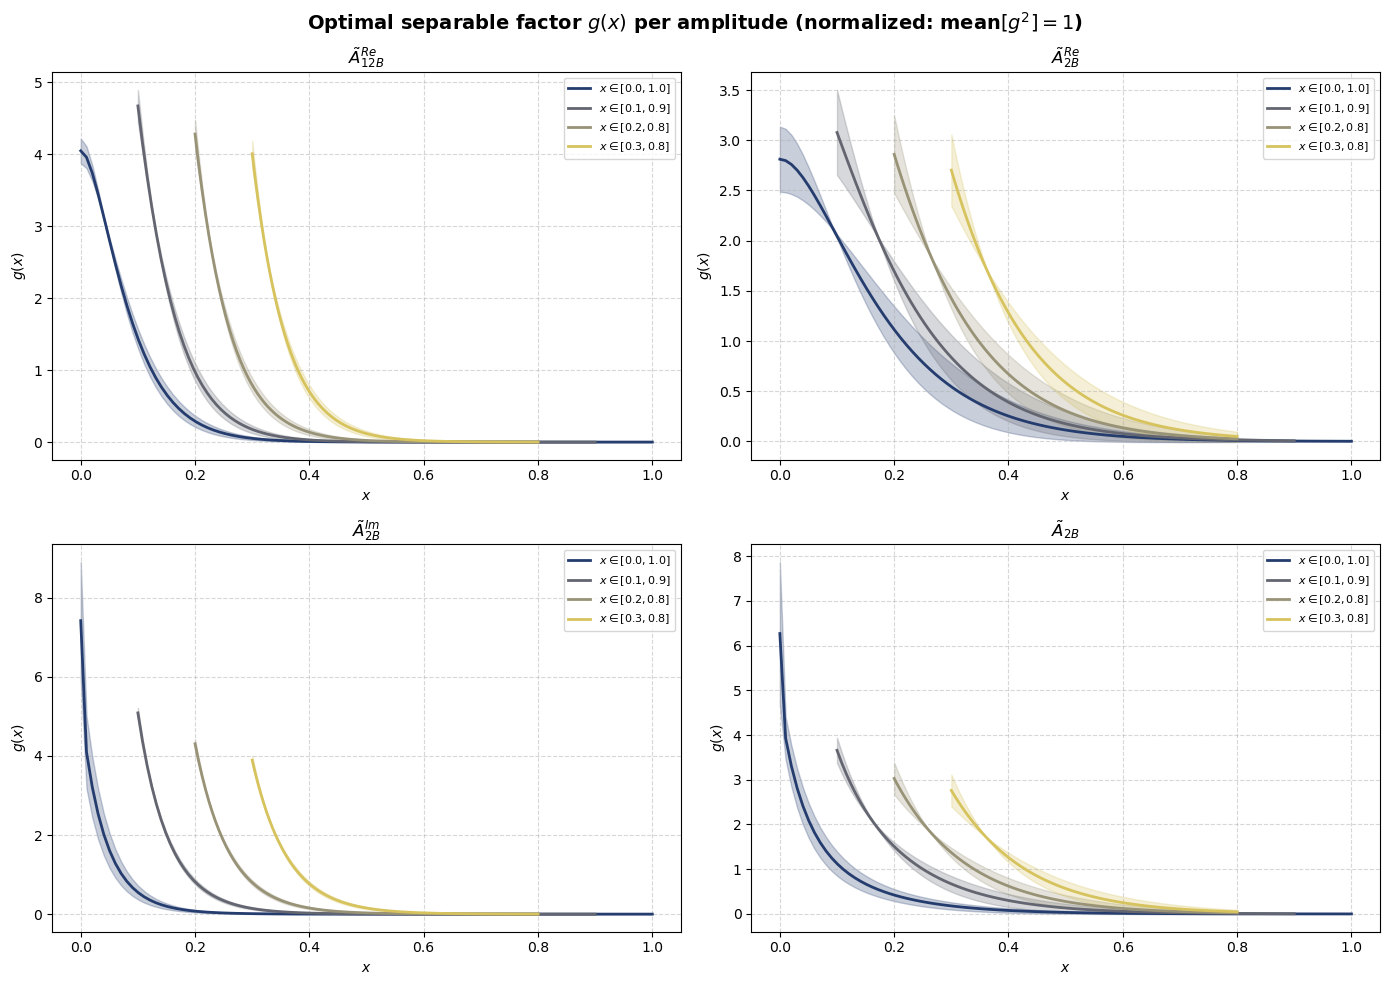

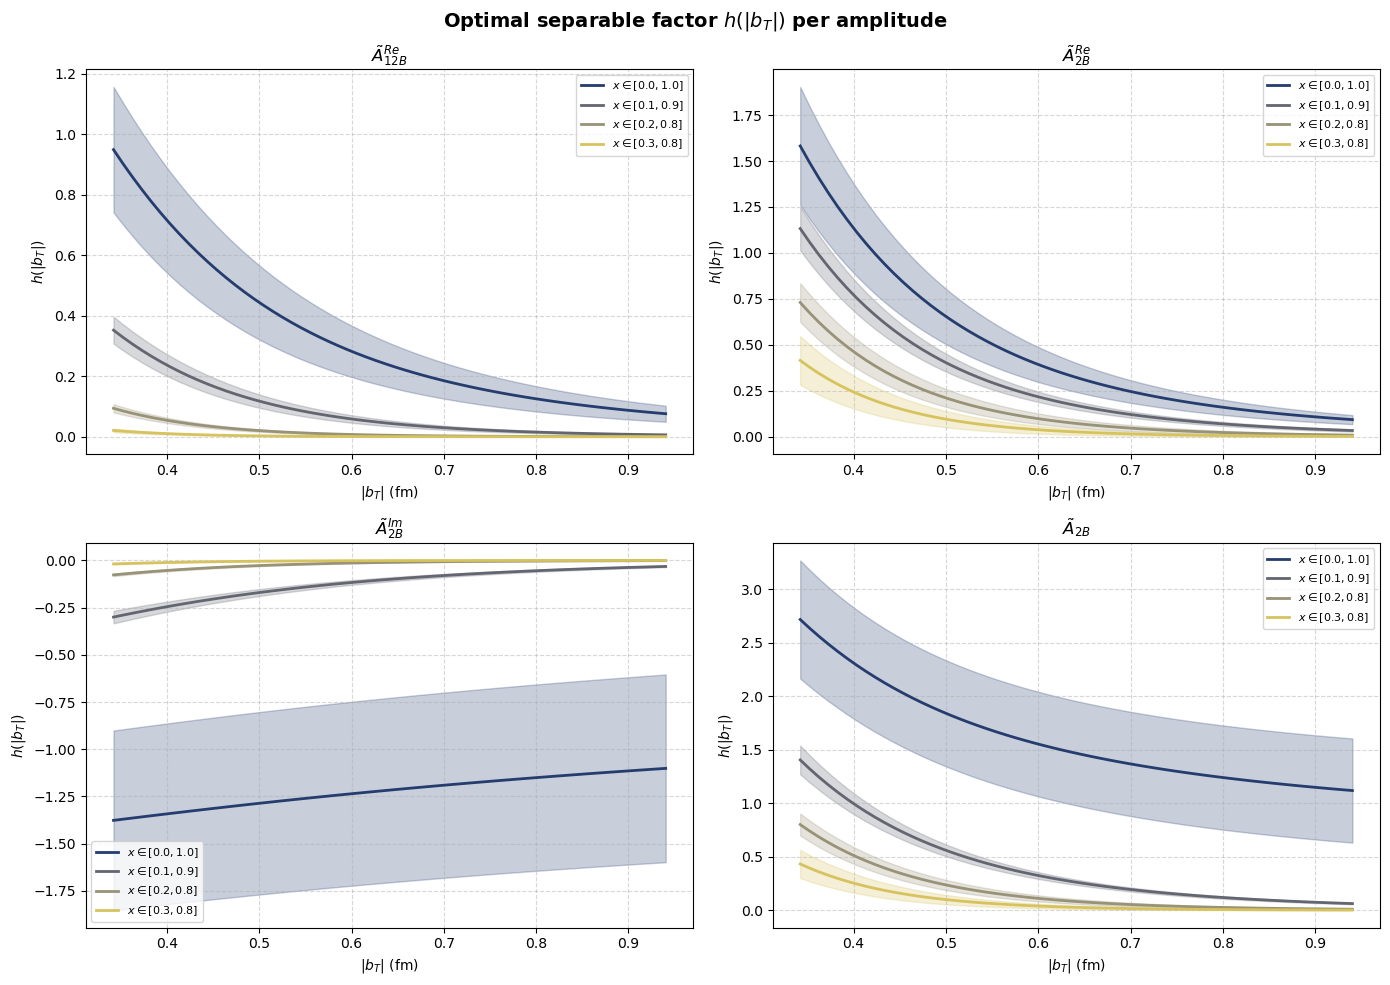

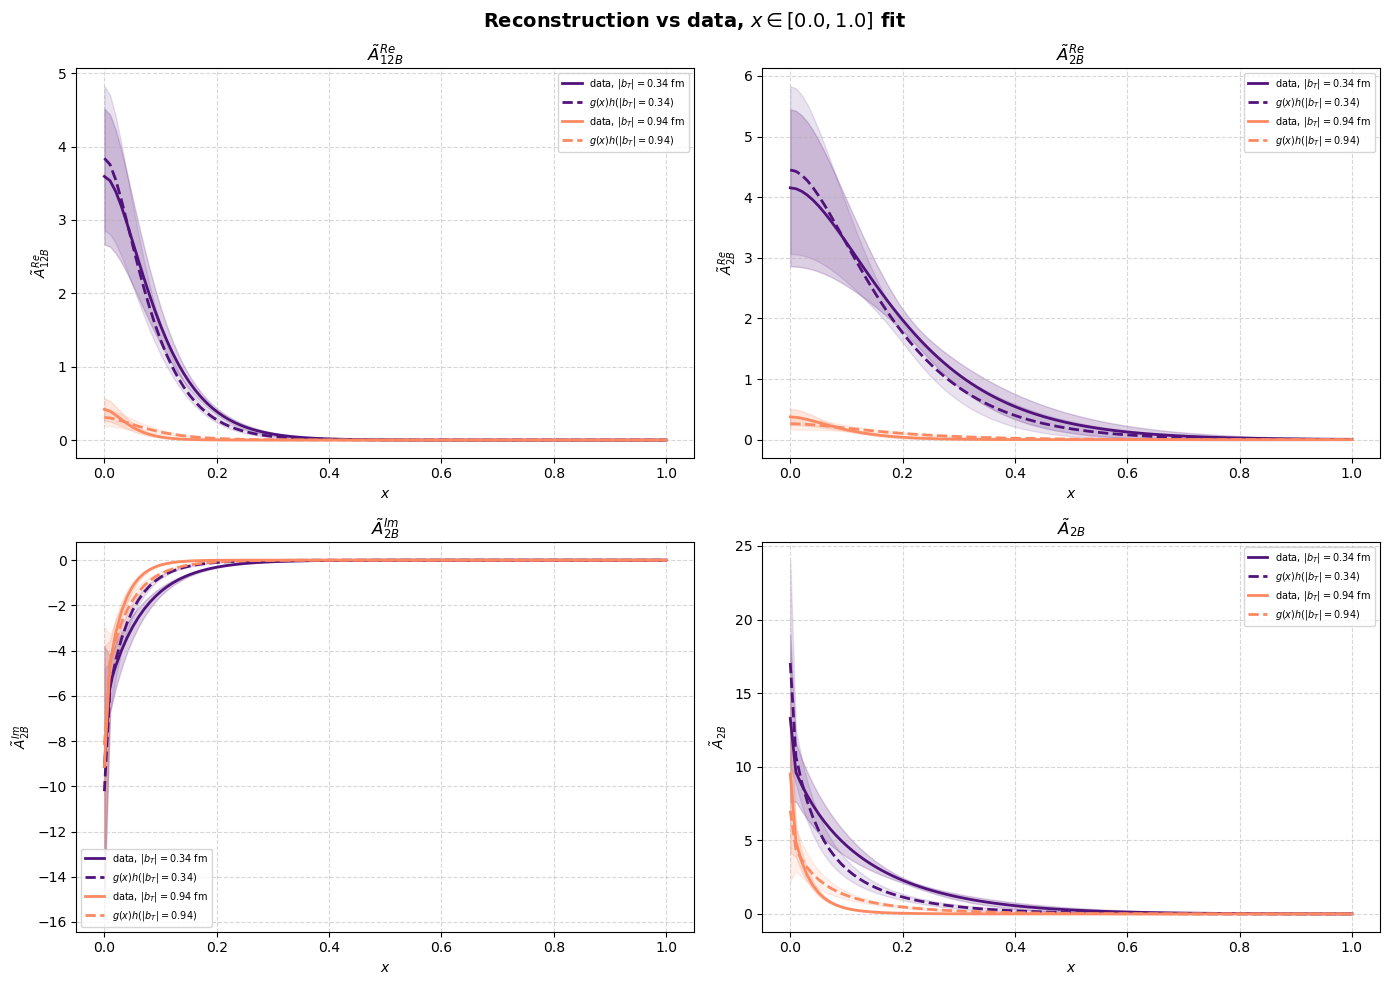

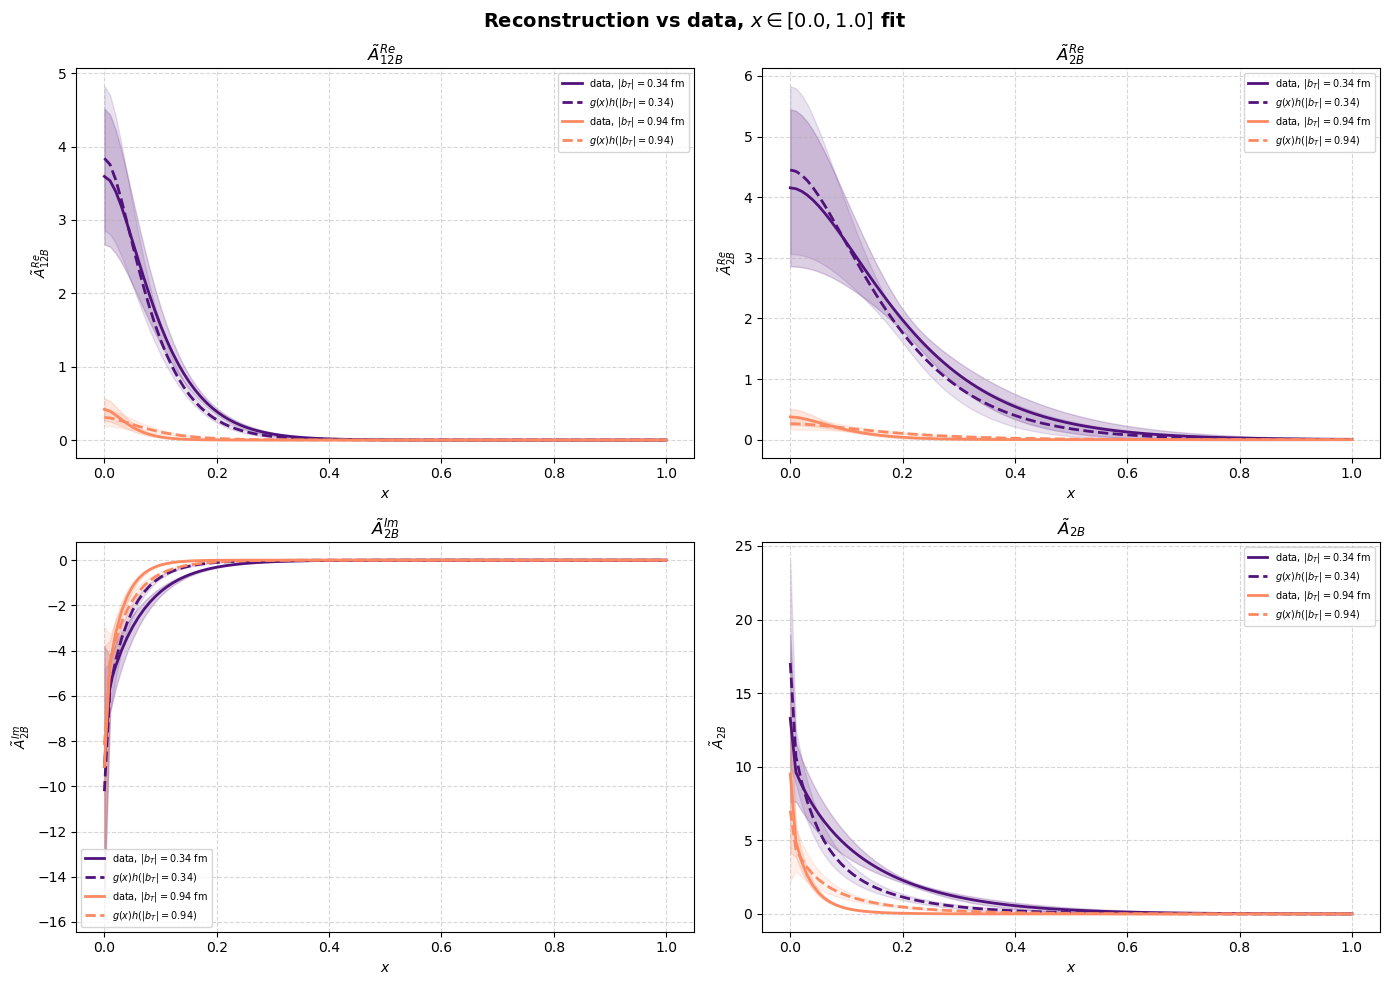

In [14]:
# ---------------------------------------------------------------------------
# 2D (x, |b_T|) factorization-distance test (factor.pl / factor.pdf ALS
# algorithm) applied to each individual extrapolated amplitude
# (tilde{A}_12B^Re, tilde{A}_2B^Re, tilde{A}_2B^Im, and their combination
# denom = re-im = f1/2), rather than to the Sivers ratio. Same algorithm and
# statistics as Factorization_Test_SiversShift.ipynb's equivalent cell (see
# there for the detailed validation: grid-resolution convergence, ALS/SVD
# self-check, iteration-count check).
#
# Unlike the Sivers ratio, these are raw amplitude values with NO division
# in their evaluation, so there is no pole risk: checked numerically that
# re, im, reA12B, denom all stay finite (no NaN/Inf) across the full grid
# and across the jackknife samples' parameter ranges, so (as with the ratio)
# no masking is applied.
# ---------------------------------------------------------------------------
def normalize_gh(g, h):
    """Fix the g<->h reciprocal-scale gauge via mean(g^2)=1 per jackknife
    sample (g*h, and therefore rratio, is unchanged by this rescaling)."""
    scale = np.sqrt(np.mean(g**2, axis=1))
    return g / scale[:, None], h * scale[:, None]


def build_obs_grid_jk(p_dict, x_grid, bT_grid, obs_key):
    """Raw per-jackknife-sample grid of one amplitude/observable
    (obs_key in {'reA12B','re','im','denom'}); shape (N_JK, N_x, N_b)."""
    b2_grid = (bT_grid / lata) ** 2
    slices = [eval_obs_jk(p_dict, x_grid, b2)[obs_key] for b2 in b2_grid]
    return np.stack(slices, axis=2)


def factorize_batch(f, tol=1e-10, max_iter=50):
    """
    factor.pl's alternating-least-squares factorization test, vectorized
    over the jackknife-sample axis (axis 0), with a convergence check
    replacing factor.pl's hardcoded 10 iterations.

    f: (N_JK, N_x, N_b) raw per-jackknife-sample grid data.
    Returns: rratio (N_JK,), g (N_JK, N_x), h (N_JK, N_b), n_iter (int)
    """
    N_JK, N_x, N_b = f.shape
    g = np.ones((N_JK, N_x))
    h = None
    prev_rratio = None

    for it in range(1, max_iter + 1):
        g2sum = np.mean(g**2, axis=1)
        h = np.einsum('kxb,kx->kb', f, g) / N_x
        h = h / g2sum[:, None]

        h2sum = np.mean(h**2, axis=1)
        g = np.einsum('kxb,kb->kx', f, h) / N_b
        g = g / h2sum[:, None]

        diff = f - g[:, :, None] * h[:, None, :]
        ms = np.mean(diff**2, axis=(1, 2))
        orignorm = np.mean(f**2, axis=(1, 2))
        rratio = np.sqrt(ms / orignorm)

        if prev_rratio is not None:
            rel_change = np.max(np.abs(rratio - prev_rratio) / (np.abs(prev_rratio) + 1e-300))
            if rel_change < tol:
                break
        prev_rratio = rratio

    return rratio, g, h, it


def run_amplitude_factorization_tests(extrapolated_jk, observables, obs_labels,
                                       x_windows=((0.0, 1.0), (0.1, 0.9), (0.2, 0.8), (0.3, 0.8)),
                                       N_x=100, N_b=60, b2_range=(9.0, 68.0)):
    bT_lo = np.sqrt(b2_range[0]) * lata
    bT_hi = np.sqrt(b2_range[1]) * lata
    bT_grid = np.linspace(bT_lo, bT_hi, N_b)

    print(f"|b_T| range: [{bT_lo:.4f}, {bT_hi:.4f}] fm ({N_b} points, fixed for all observables/windows)\n")

    results = {}
    for obs in observables:
        print(f"=== {obs_labels[obs]}  ({obs}) ===")
        results[obs] = {}
        for (xlo, xhi) in x_windows:
            x_grid = np.linspace(xlo, xhi, N_x)

            f = build_obs_grid_jk(extrapolated_jk, x_grid, bT_grid, obs)
            n_bad = np.count_nonzero(~np.isfinite(f))
            if n_bad:
                print(f"  [warning] {obs}, x in [{xlo},{xhi}]: {n_bad} non-finite grid points "
                      f"out of {f.size} -- results below may be unreliable.")

            rratio_jk, g_jk, h_jk, n_iter = factorize_batch(f)
            g_jk, h_jk = normalize_gh(g_jk, h_jk)

            # Self-check: the ALS fixed point must match the SVD-based rank-1
            # distance (same least-squares problem, solved two different ways).
            for k in (0, f.shape[0] // 2, f.shape[0] - 1):
                s = np.linalg.svd(f[k], compute_uv=False)
                rratio_svd = np.sqrt(1.0 - s[0]**2 / np.sum(s**2))
                assert np.isclose(rratio_jk[k], rratio_svd, atol=1e-6, rtol=1e-6), (
                    f"ALS/SVD mismatch for {obs}, sample {k}, window [{xlo},{xhi}]: "
                    f"{rratio_jk[k]} vs {rratio_svd}"
                )

            mean, err = Jackknife(rratio_jk)
            print(f"  x in [{xlo}, {xhi}]  (converged in {n_iter} iterations): {fmt_err(mean, err)}")

            results[obs][(xlo, xhi)] = {
                'x_grid': x_grid, 'bT_grid': bT_grid,
                'g_jk': g_jk, 'h_jk': h_jk,
                'rratio_jk': rratio_jk, 'rratio_mean': mean, 'rratio_err': err,
            }
        print()

    return results


amplitude_factorization_results = run_amplitude_factorization_tests(extrapolated_jk, observables, obs_labels)


def plot_amplitude_gh_grid(results, observables, obs_labels):
    """2x2 grid (one subplot per observable) of g(x), overlaying all
    x-windows with jackknife bands."""
    example_obs = observables[0]
    x_windows = list(results[example_obs].keys())
    colors = plt.cm.cividis(np.linspace(0.15, 0.85, len(x_windows)))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, obs in zip(axes.flatten(), observables):
        for c, win in zip(colors, x_windows):
            r = results[obs][win]
            m, e = jk_stats(r['g_jk'], axis=0)
            ax.plot(r['x_grid'], m, color=c, linewidth=2, label=fr"$x\in[{win[0]},{win[1]}]$")
            ax.fill_between(r['x_grid'], m - e, m + e, color=c, alpha=0.25)
        ax.set_title(f"${obs_labels[obs]}$")
        ax.set_xlabel('$x$')
        ax.set_ylabel('$g(x)$')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    fig.suptitle(r'Optimal separable factor $g(x)$ per amplitude (normalized: mean$[g^2]=1$)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Factorization_Amplitudes_g_of_x_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


def plot_amplitude_h_grid(results, observables, obs_labels):
    """2x2 grid (one subplot per observable) of h(|b_T|), overlaying all
    x-windows with jackknife bands."""
    example_obs = observables[0]
    x_windows = list(results[example_obs].keys())
    colors = plt.cm.cividis(np.linspace(0.15, 0.85, len(x_windows)))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, obs in zip(axes.flatten(), observables):
        for c, win in zip(colors, x_windows):
            r = results[obs][win]
            m, e = jk_stats(r['h_jk'], axis=0)
            ax.plot(r['bT_grid'], m, color=c, linewidth=2, label=fr"$x\in[{win[0]},{win[1]}]$")
            ax.fill_between(r['bT_grid'], m - e, m + e, color=c, alpha=0.25)
        ax.set_title(f"${obs_labels[obs]}$")
        ax.set_xlabel(r'$|b_T|$ (fm)')
        ax.set_ylabel(r'$h(|b_T|)$')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    fig.suptitle(r'Optimal separable factor $h(|b_T|)$ per amplitude', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Factorization_Amplitudes_h_of_bT_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


def plot_amplitude_reconstruction_grid(results, extrapolated_jk, observables, obs_labels,
                                        recon_window=(0.0, 1.0), recon_bT_idx=(0, -1)):
    """2x2 grid (one subplot per observable): g(x)*h(b_T) reconstruction vs
    the actual amplitude data, at a couple of |b_T| slices."""
    colors_bt = plt.cm.magma(np.linspace(0.25, 0.75, len(recon_bT_idx)))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, obs in zip(axes.flatten(), observables):
        r = results[obs][recon_window]
        x_grid = r['x_grid']
        bT_grid = r['bT_grid']

        for c, ib in zip(colors_bt, recon_bT_idx):
            bT_val = bT_grid[ib]
            b2_val = (bT_val / lata) ** 2

            obs_actual = eval_obs_jk(extrapolated_jk, x_grid, b2_val)[obs]
            m_act, e_act = jk_stats(obs_actual, axis=0)

            recon_jk = r['g_jk'] * r['h_jk'][:, [ib]]
            m_rec, e_rec = jk_stats(recon_jk, axis=0)

            ax.plot(x_grid, m_act, color=c, linewidth=2, linestyle='-',
                    label=fr"data, $|b_T|={bT_val:.2f}$ fm")
            ax.fill_between(x_grid, m_act - e_act, m_act + e_act, color=c, alpha=0.2)
            ax.plot(x_grid, m_rec, color=c, linewidth=2, linestyle='--',
                    label=fr"$g(x)h(|b_T|={bT_val:.2f})$")
            ax.fill_between(x_grid, m_rec - e_rec, m_rec + e_rec, color=c, alpha=0.12)

        ax.set_title(f"${obs_labels[obs]}$")
        ax.set_xlabel('$x$')
        ax.set_ylabel(f"${obs_labels[obs]}$")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7)

    fig.suptitle(fr'Reconstruction vs data, $x\in[{recon_window[0]},{recon_window[1]}]$ fit',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Factorization_Amplitudes_Reconstruction_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


plot_amplitude_gh_grid(amplitude_factorization_results, observables, obs_labels)
plot_amplitude_h_grid(amplitude_factorization_results, observables, obs_labels)
plot_amplitude_reconstruction_grid(amplitude_factorization_results, extrapolated_jk, observables, obs_labels)


## Part 1: Extrapolated Parameters

We first test the factorization of the amplitudes constructed from the $\hat{\zeta} \to \infty$ extrapolated parameters.

Plotting extrapolated R_b(x)


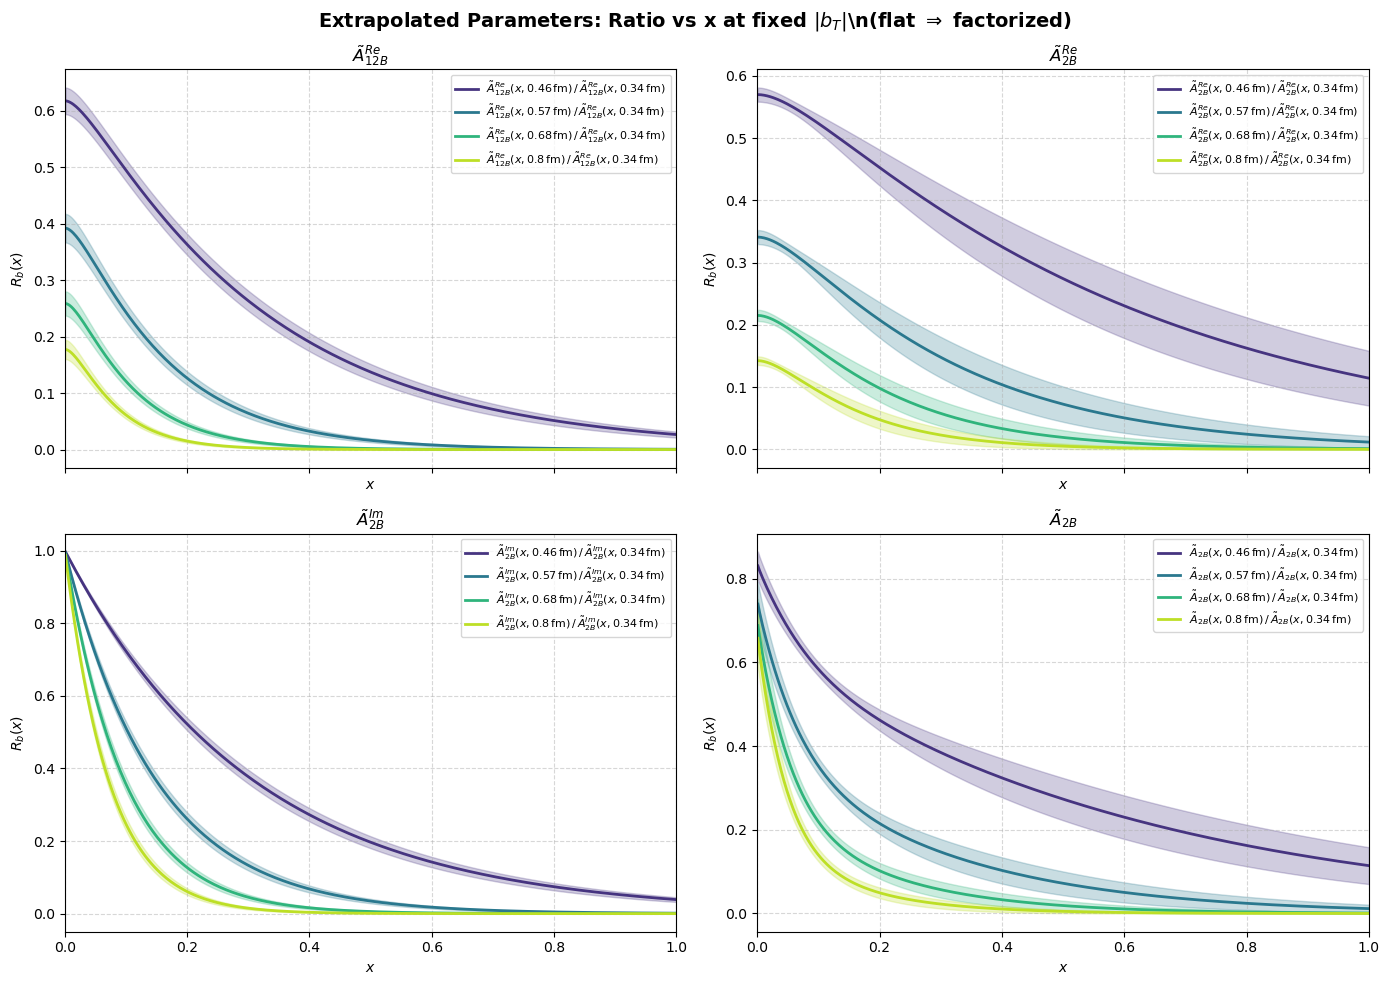

In [8]:
print("Plotting extrapolated R_b(x)")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for ax, obs in zip(axes.flatten(), observables):
    obs_ref = eval_obs_jk(extrapolated_jk, x_grid, b2_ref)[obs]
    bad_ref = mask_near_pole(obs_ref, n_sigma=2.0, label=f"Extrapolated {obs} at b_ref")
    for c, b2_i in zip(colors_fan, b2_fan):
        bT_i_fm = np.round(np.sqrt(b2_i) * lata, 2)
        obs_i = eval_obs_jk(extrapolated_jk, x_grid, b2_i)[obs]
        ratio_jk = obs_i / obs_ref
        m, e = jk_stats(ratio_jk, axis=0)
        m[bad_ref] = np.nan
        e[bad_ref] = np.nan
        label = fr"${obs_labels[obs]}(x,{bT_i_fm}\,{{\rm fm}})\,/\,{obs_labels[obs]}(x,{bT_ref_fm}\,{{\rm fm}})$"
        ax.plot(x_grid, m, color=c, linewidth=2, label=label)
        ax.fill_between(x_grid, m - e, m + e, color=c, alpha=0.25)
    ax.set_title(f"${obs_labels[obs]}$")
    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$R_b(x)$')
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
fig.suptitle('Extrapolated Parameters: Ratio vs x at fixed $|b_T|$\\n(flat $\\Rightarrow$ factorized)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.show()

Plotting extrapolated R_x(b)


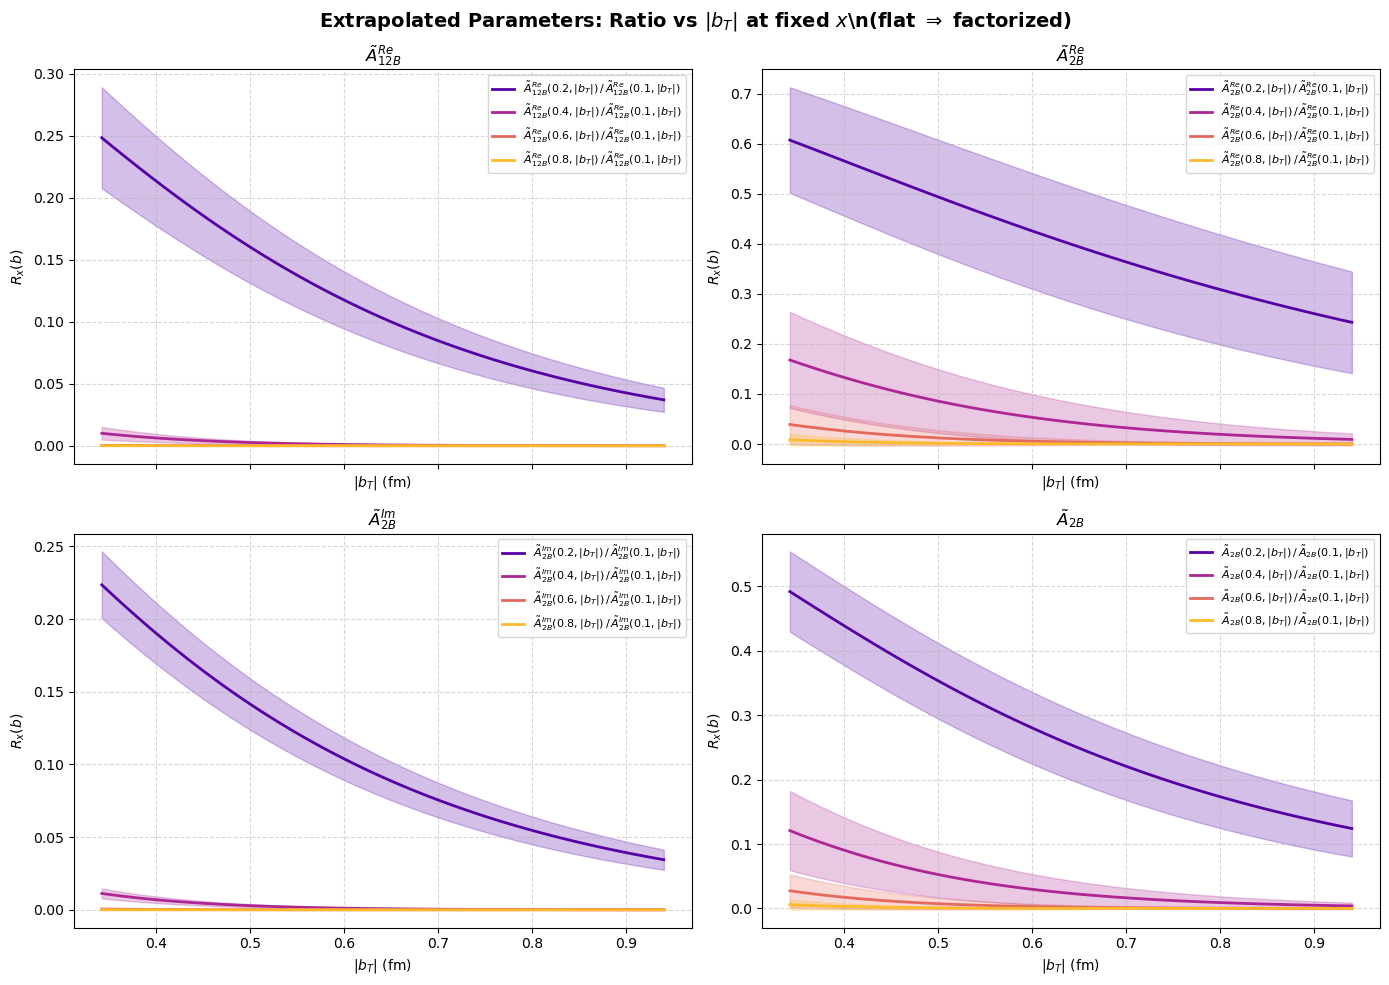

In [9]:
print("Plotting extrapolated R_x(b)")
b2_grid = np.linspace(9.0, 68.0, 120)
bT_grid = np.sqrt(b2_grid) * lata
x_ref = 0.1
x_fan = [0.2, 0.4, 0.6, 0.8]
colors_fan_x = plt.cm.plasma(np.linspace(0.15, 0.85, len(x_fan)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for ax, obs in zip(axes.flatten(), observables):
    obs_ref_b = eval_obs_over_b2(extrapolated_jk, x_ref, b2_grid)[obs]
    bad_ref = mask_near_pole(obs_ref_b, n_sigma=2.0, label=f"Extrapolated {obs} at x_ref")
    for c, x_i in zip(colors_fan_x, x_fan):
        obs_i_b = eval_obs_over_b2(extrapolated_jk, x_i, b2_grid)[obs]
        ratio_jk_b = obs_i_b / obs_ref_b
        m_b, e_b = jk_stats(ratio_jk_b, axis=0)
        m_b[bad_ref] = np.nan
        e_b[bad_ref] = np.nan
        label = fr"${obs_labels[obs]}({x_i},|b_T|)\,/\,{obs_labels[obs]}({x_ref},|b_T|)$"
        ax.plot(bT_grid, m_b, color=c, linewidth=2, label=label)
        ax.fill_between(bT_grid, m_b - e_b, m_b + e_b, color=c, alpha=0.25)
    ax.set_title(f"${obs_labels[obs]}$")
    ax.set_xlabel('$|b_T|$ (fm)')
    ax.set_ylabel(r'$R_x(b)$')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
fig.suptitle('Extrapolated Parameters: Ratio vs $|b_T|$ at fixed $x$\\n(flat $\\Rightarrow$ factorized)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.show()

## Part 2: Finite $P_L$ Parameters

Now we test the factorization for each of the finite momentum parameters without extrapolation.

Plotting finite P_L R_b(x)


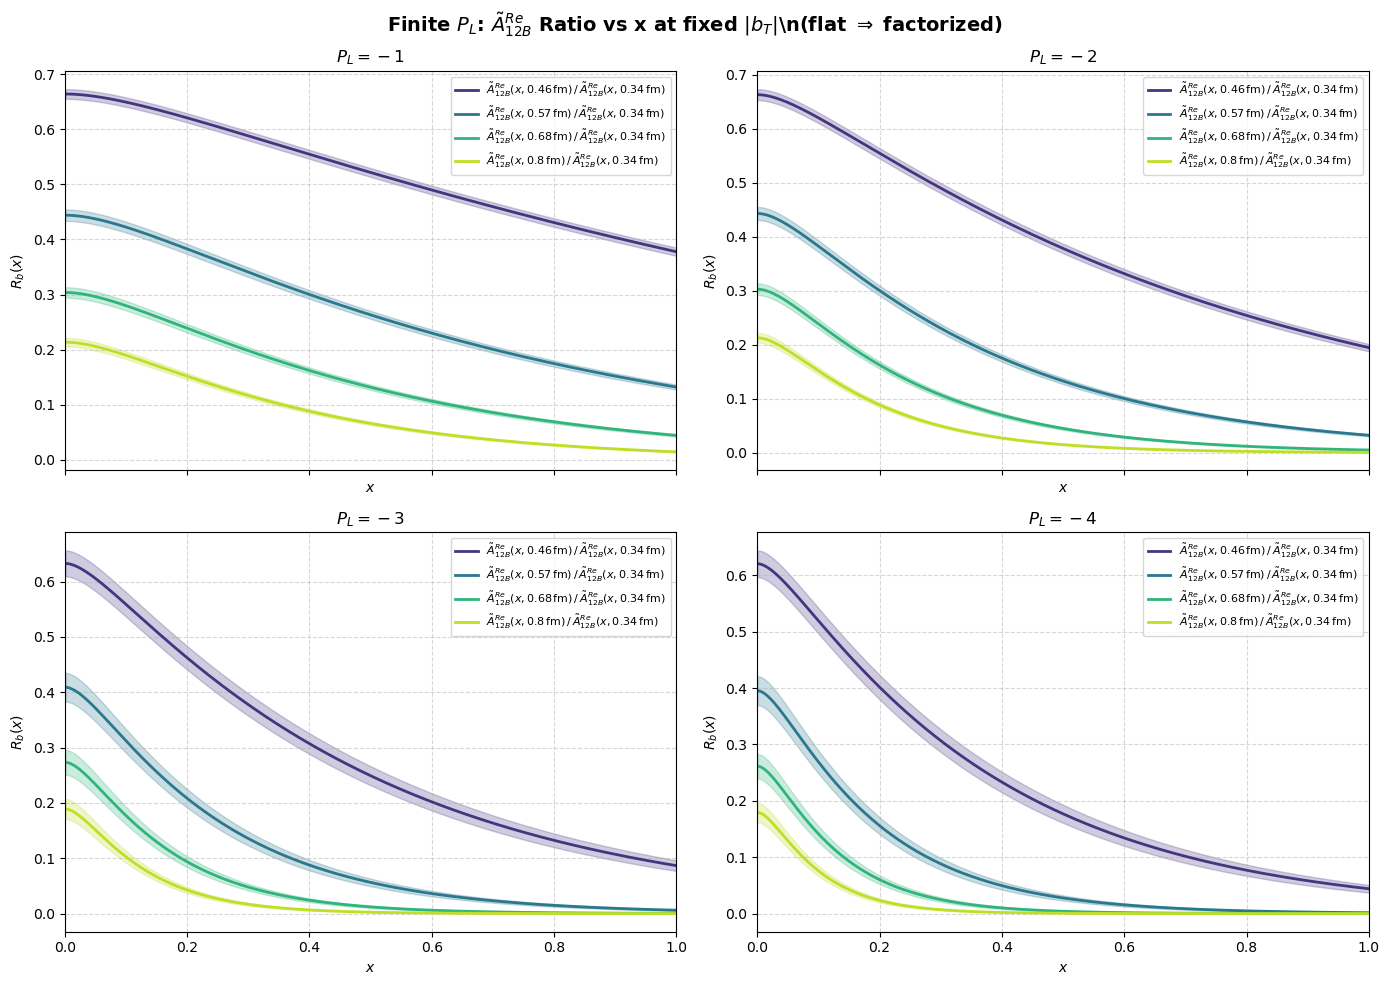

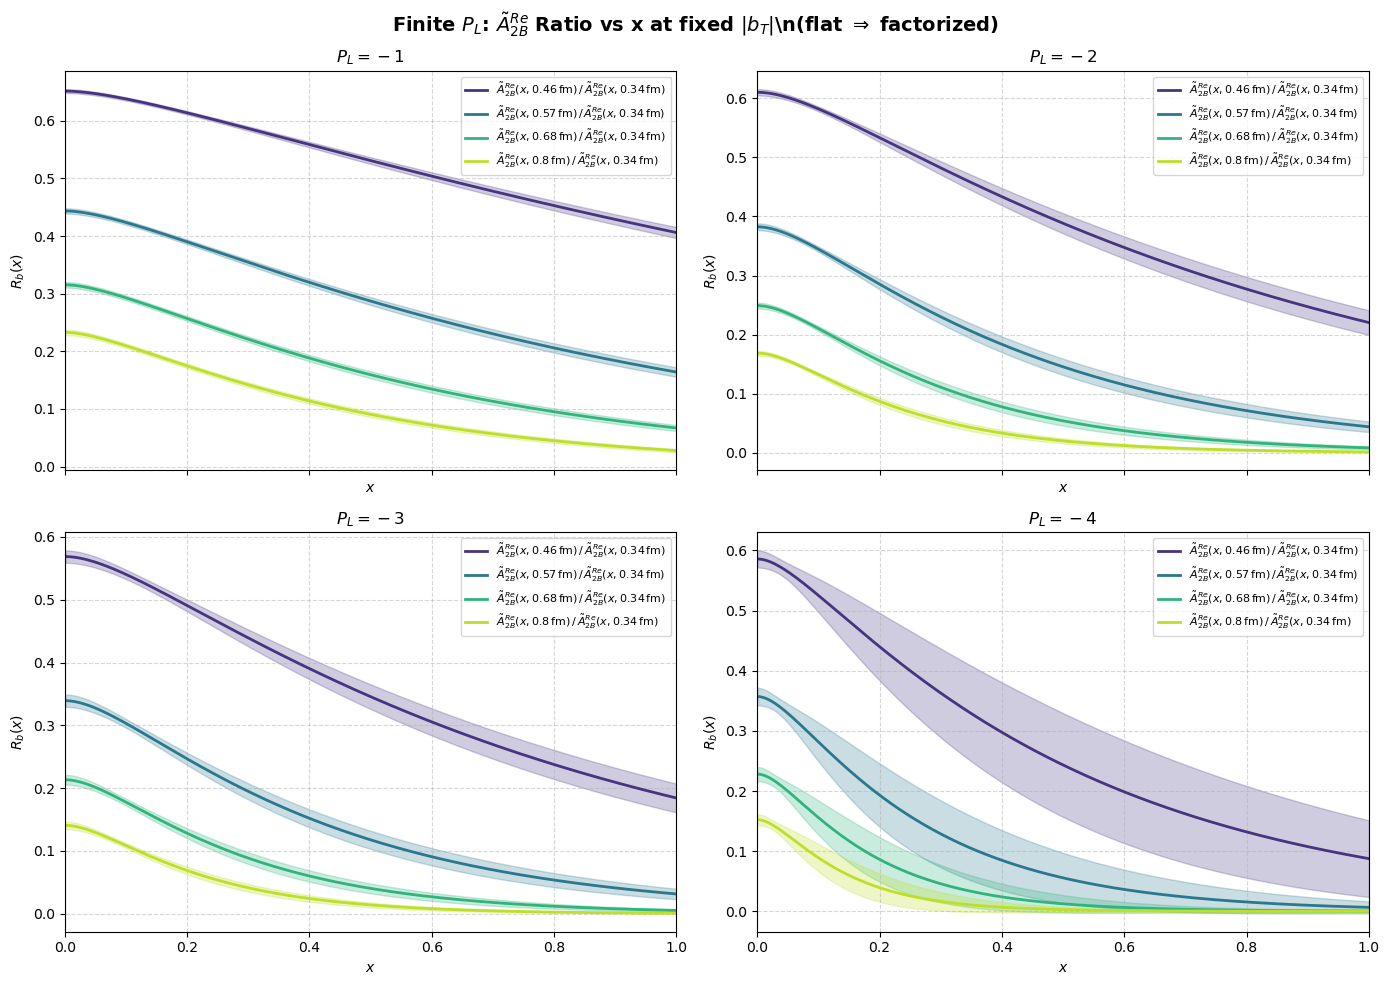

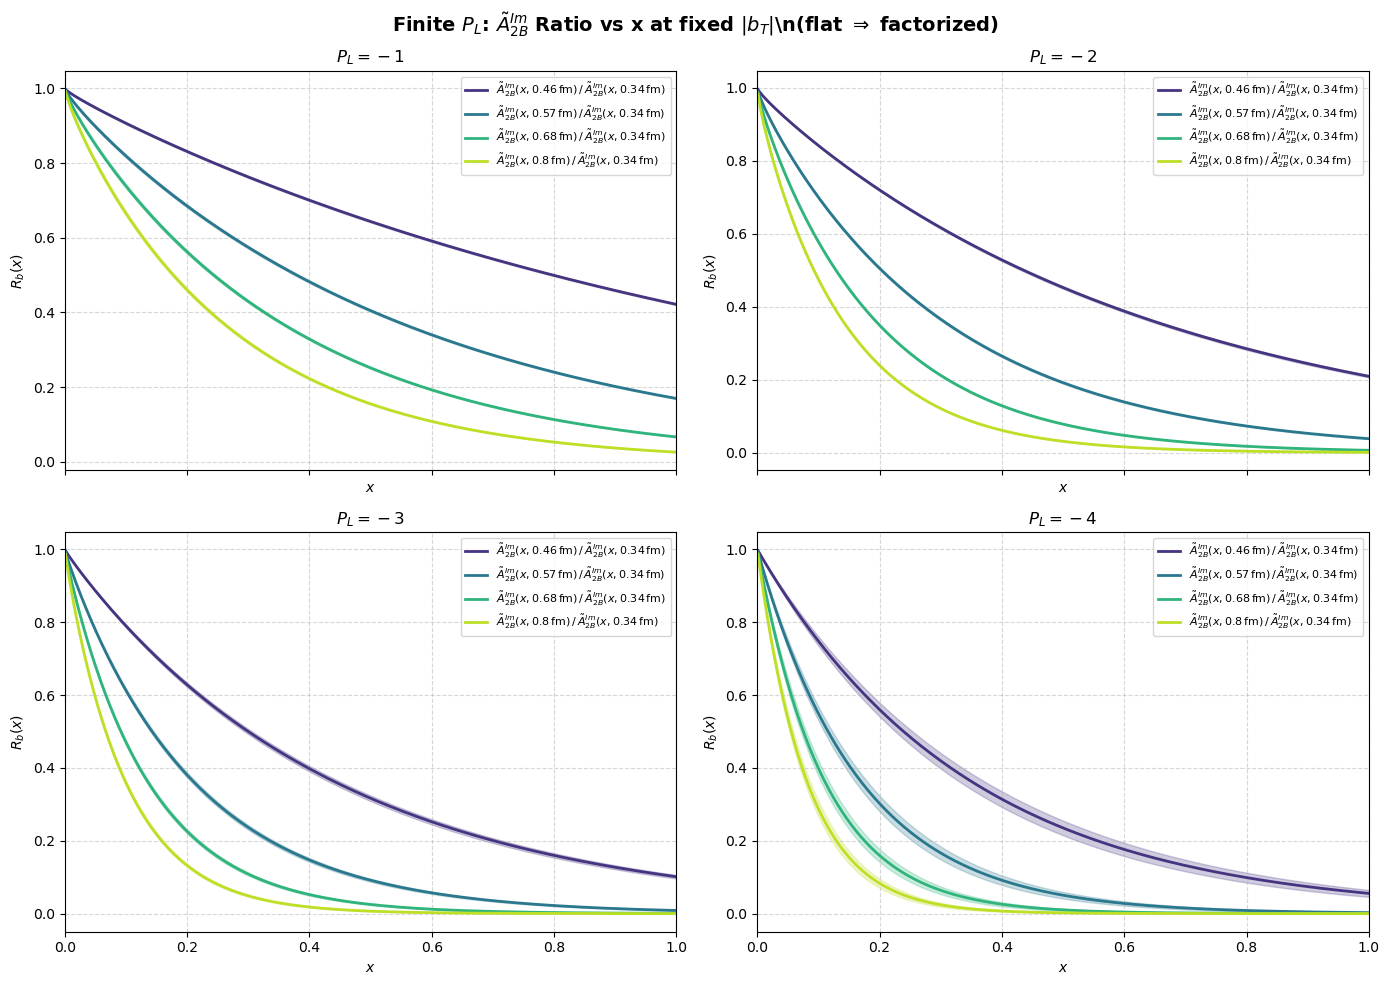

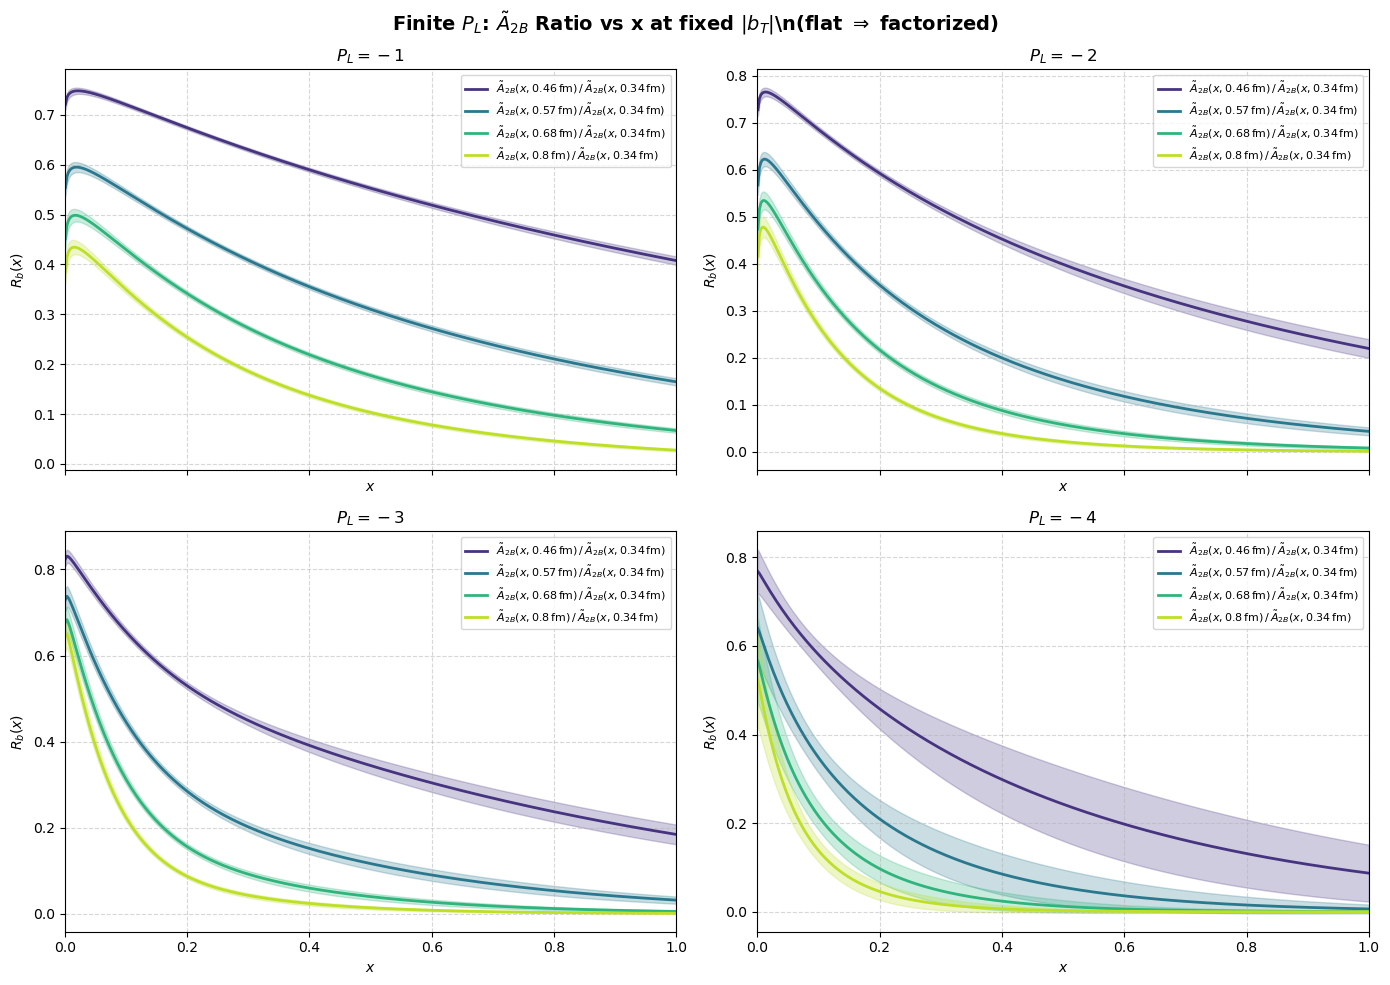

In [10]:
print("Plotting finite P_L R_b(x)")
for obs in observables:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    for ax, pl in zip(axes.flatten(), PL_LIST_FINITE):
        p_dict = finite_pl_params[pl]
        obs_ref = eval_obs_jk(p_dict, x_grid, b2_ref)[obs]
        bad_ref = mask_near_pole(obs_ref, n_sigma=2.0, label=f"PL={pl} {obs} at b_ref")
        for c, b2_i in zip(colors_fan, b2_fan):
            bT_i_fm = np.round(np.sqrt(b2_i) * lata, 2)
            obs_i = eval_obs_jk(p_dict, x_grid, b2_i)[obs]
            ratio_jk = obs_i / obs_ref
            m, e = jk_stats(ratio_jk, axis=0)
            m[bad_ref] = np.nan
            e[bad_ref] = np.nan
            label = fr"${obs_labels[obs]}(x,{bT_i_fm}\,{{\rm fm}})\,/\,{obs_labels[obs]}(x,{bT_ref_fm}\,{{\rm fm}})$"
            ax.plot(x_grid, m, color=c, linewidth=2, label=label)
            ax.fill_between(x_grid, m - e, m + e, color=c, alpha=0.25)
        ax.set_title(f"$P_L = {pl}$")
        ax.set_xlabel('$x$')
        ax.set_ylabel(r'$R_b(x)$')
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    fig.suptitle(f'Finite $P_L$: ${obs_labels[obs]}$ Ratio vs x at fixed $|b_T|$\\n(flat $\\Rightarrow$ factorized)', fontsize=14, fontweight='bold')
    plt.tight_layout()

Plotting finite P_L R_x(b)


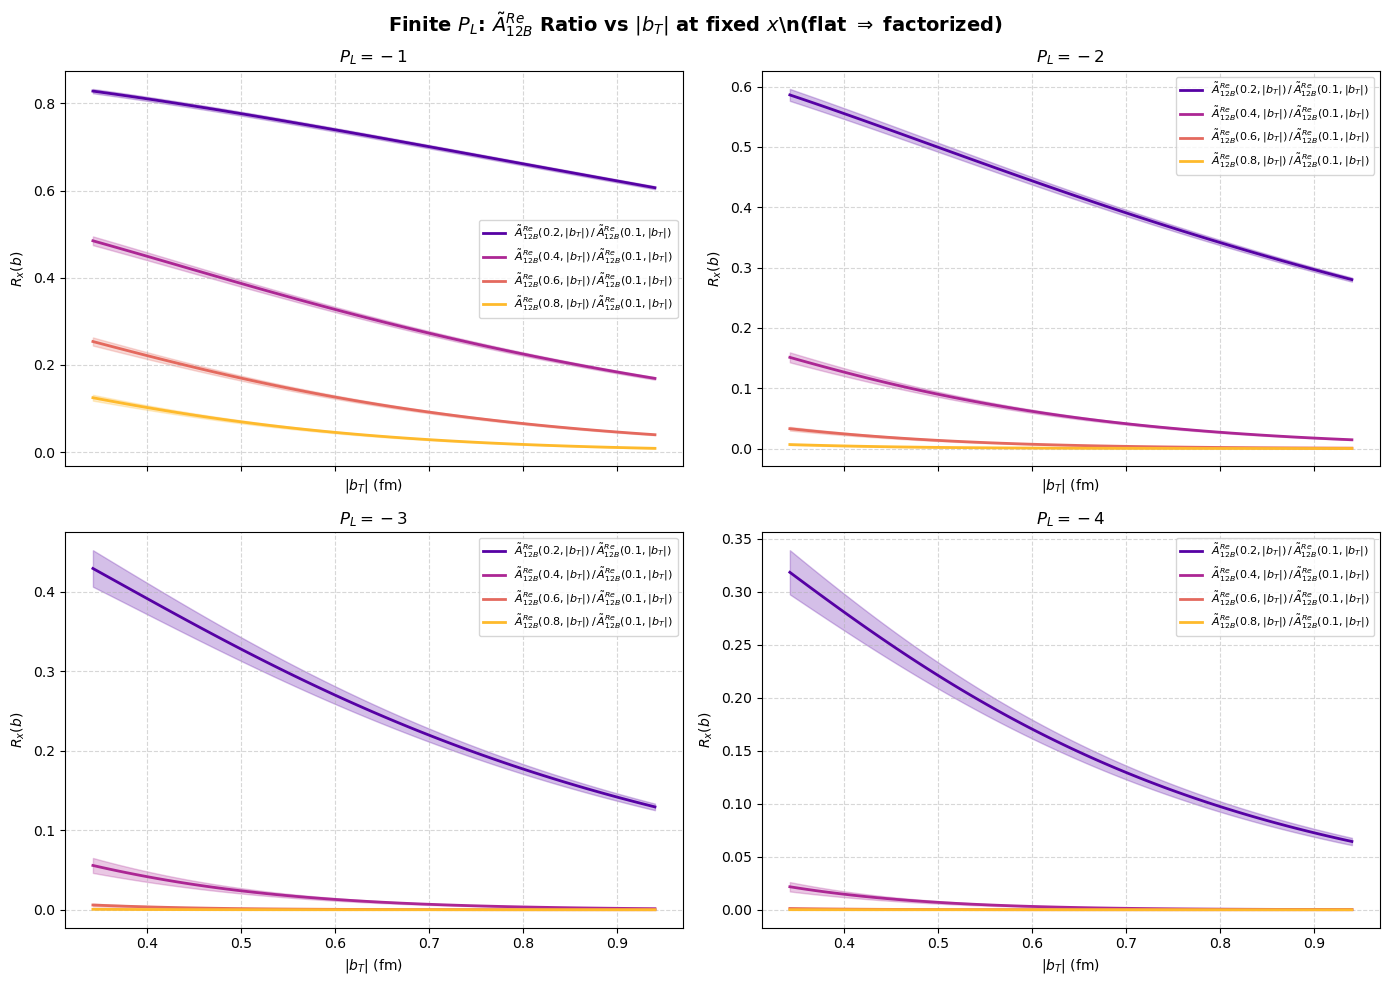

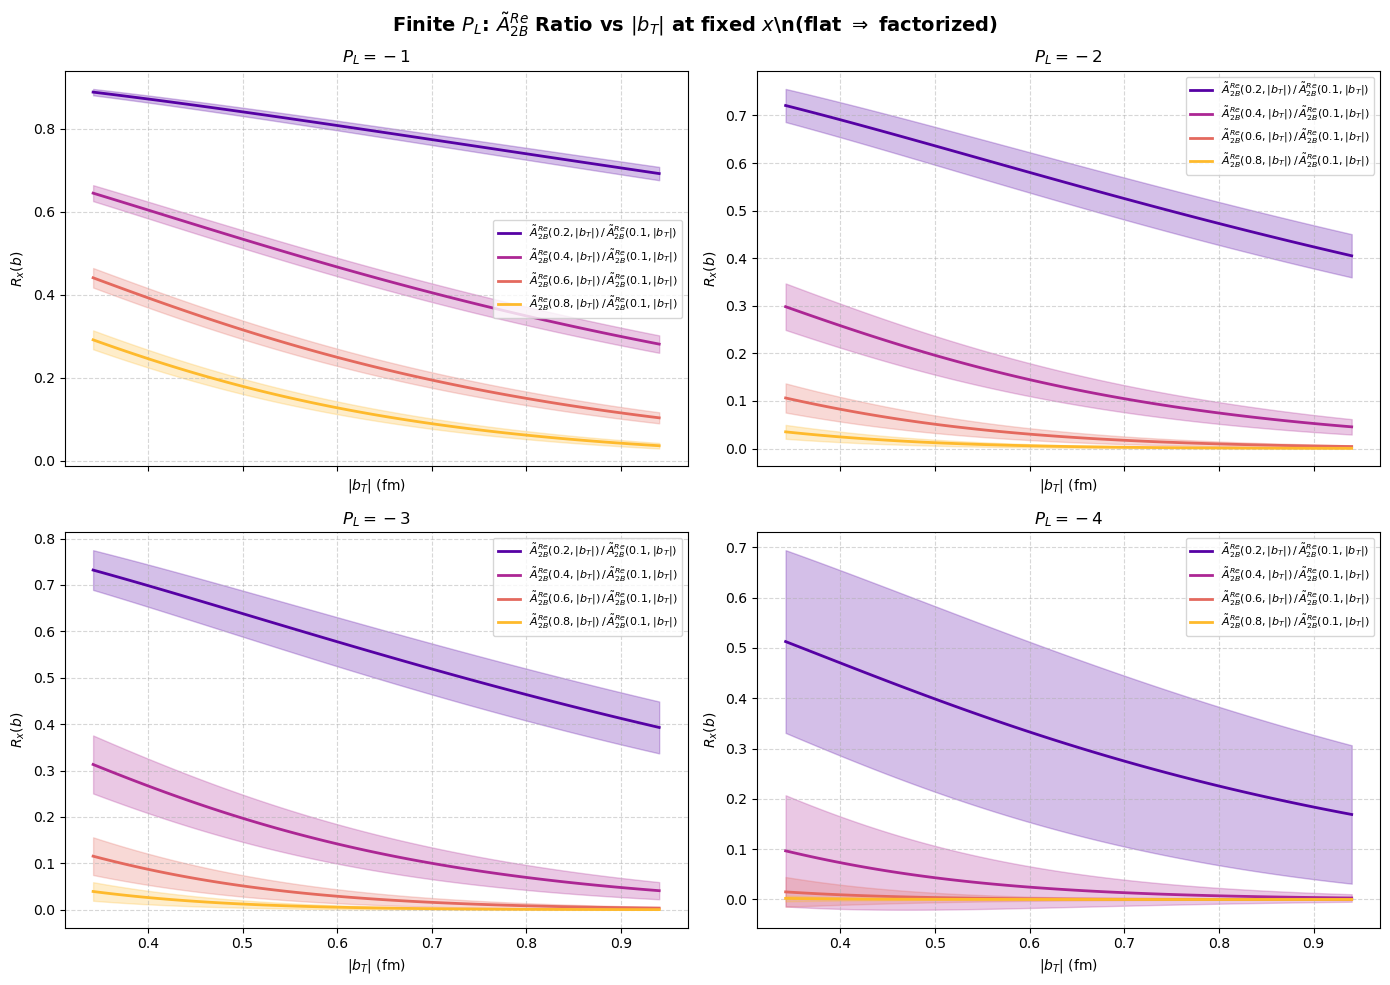

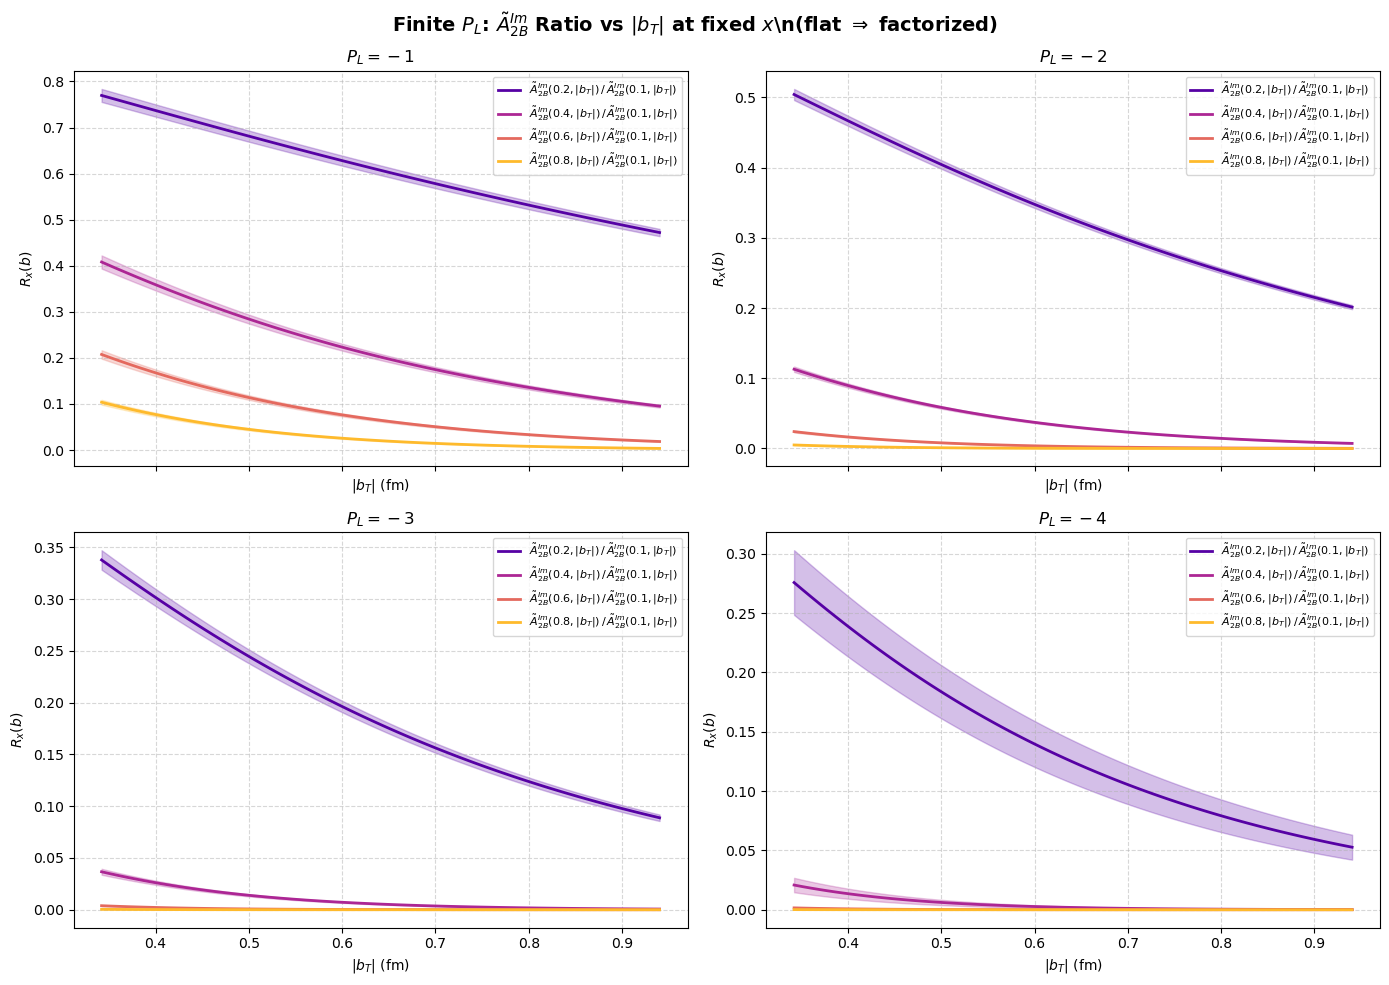

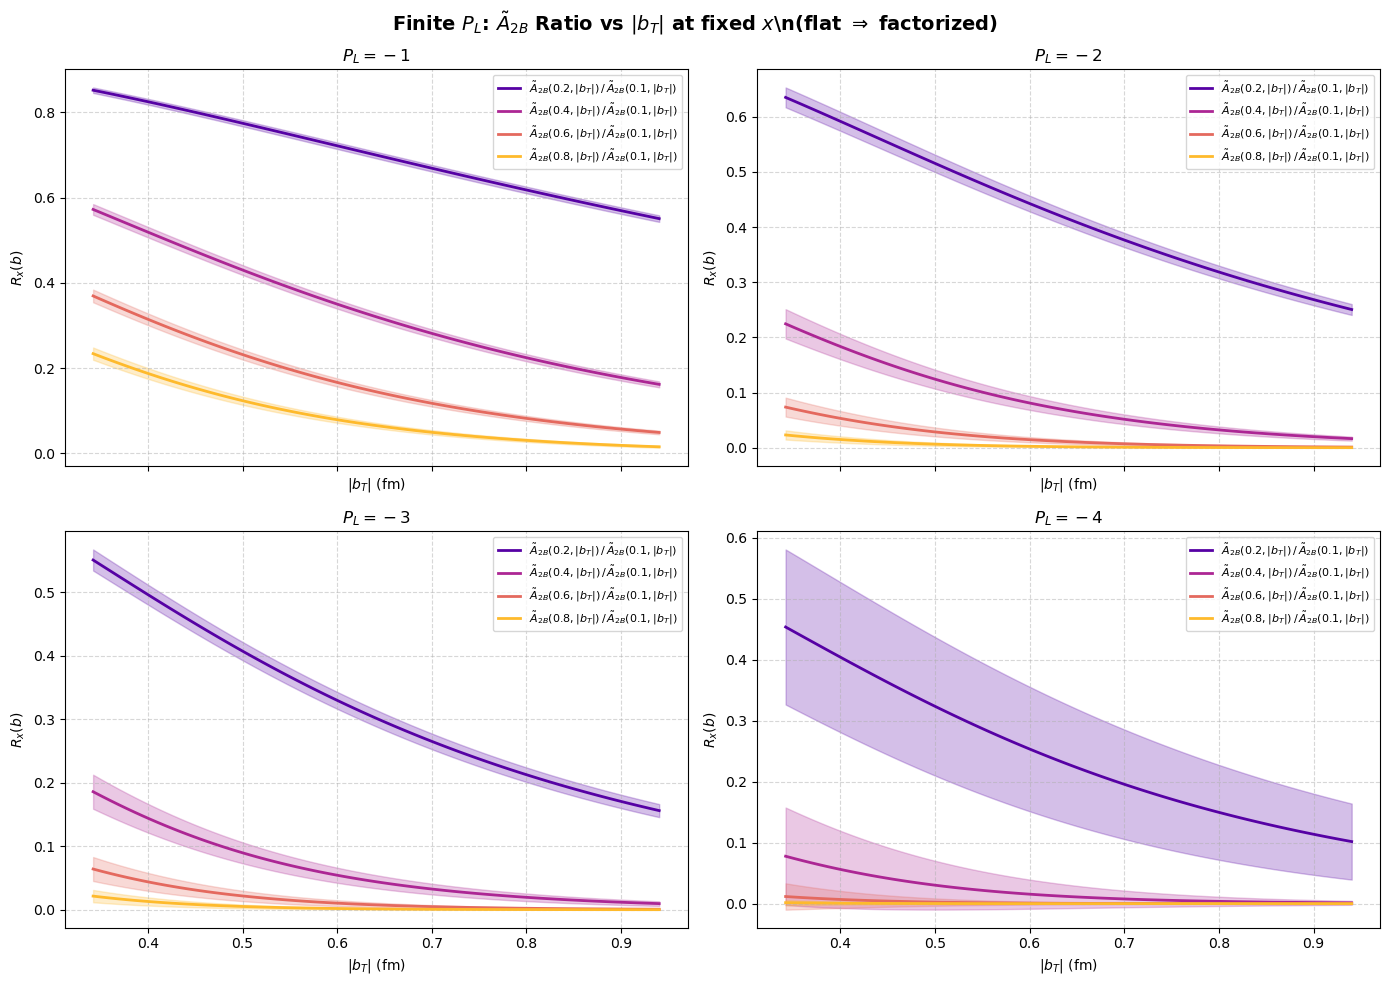

In [11]:
print("Plotting finite P_L R_x(b)")
for obs in observables:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    for ax, pl in zip(axes.flatten(), PL_LIST_FINITE):
        p_dict = finite_pl_params[pl]
        obs_ref_b = eval_obs_over_b2(p_dict, x_ref, b2_grid)[obs]
        bad_ref = mask_near_pole(obs_ref_b, n_sigma=2.0, label=f"PL={pl} {obs} at x_ref")
        for c, x_i in zip(colors_fan_x, x_fan):
            obs_i_b = eval_obs_over_b2(p_dict, x_i, b2_grid)[obs]
            ratio_jk_b = obs_i_b / obs_ref_b
            m_b, e_b = jk_stats(ratio_jk_b, axis=0)
            m_b[bad_ref] = np.nan
            e_b[bad_ref] = np.nan
            label = fr"${obs_labels[obs]}({x_i},|b_T|)\,/\,{obs_labels[obs]}({x_ref},|b_T|)$"
            ax.plot(bT_grid, m_b, color=c, linewidth=2, label=label)
            ax.fill_between(bT_grid, m_b - e_b, m_b + e_b, color=c, alpha=0.25)
        ax.set_title(f"$P_L = {pl}$")
        ax.set_xlabel('$|b_T|$ (fm)')
        ax.set_ylabel(r'$R_x(b)$')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    fig.suptitle(f'Finite $P_L$: ${obs_labels[obs]}$ Ratio vs $|b_T|$ at fixed $x$\\n(flat $\\Rightarrow$ factorized)', fontsize=14, fontweight='bold')
    plt.tight_layout()

In [12]:
print("All OK!")

All OK!
